In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [3]:
len(X), len(y)
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


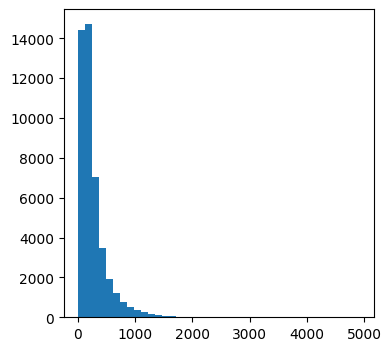

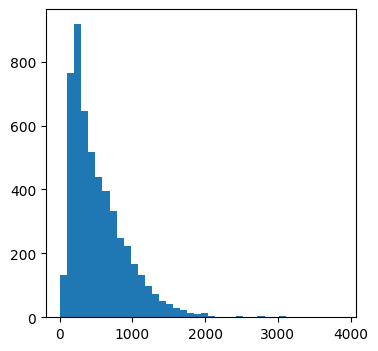

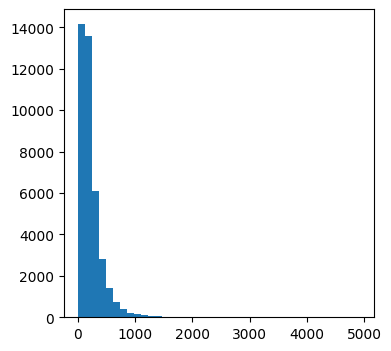

In [4]:
plt.figure(figsize=(4,4))
plt.hist(X['duration'], bins=40)
plt.show()

plt.figure(figsize=(4,4))
plt.hist((X[y['y'] == 'yes'])['duration'], bins=40)
plt.show()

plt.figure(figsize=(4,4))
plt.hist((X[y['y'] == 'no'])['duration'], bins=40)
plt.show()

In [5]:
import ipywidgets as widgets

In [6]:
def plot_balance_for_age(age_range):
    min_age, max_age = age_range
    
    plt.figure(figsize=(8,8))
    XX = X[X['age'].between(min_age, max_age)]

    plt.hist(XX['balance'], bins=100)
    plt.grid(True)
    plt.show()

widgets.interact(
    plot_balance_for_age,
    age_range=widgets.IntRangeSlider(
        value=[25,100],
        min=0,
        max=100,
        step=1,
        description='Age:'
    )
)

interactive(children=(IntRangeSlider(value=(25, 100), description='Age:'), Output()), _dom_classes=('widget-in…

<function __main__.plot_balance_for_age(age_range)>

Percentage of positive samples for t=360 : 32.56360915116528
0 4918


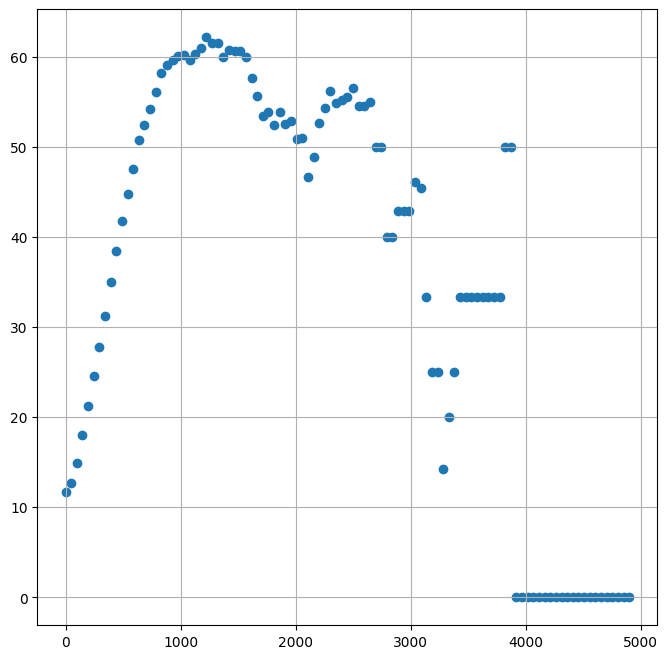

In [7]:
t = 360
print(f'Percentage of positive samples for t={t} : {(y[X['duration'] > t]['y'] == 'yes').mean()*100}')

def plot_different_threshold(X, y):
    min_duration, max_duration = X['duration'].min(), X['duration'].max()
    print(min_duration, max_duration)

    xs = []
    ys = []
    for t in range(min_duration, max_duration, (max_duration - min_duration) // 100):
        xs.append(t)
        ys.append((y[X['duration'] > t]['y'] == 'yes').mean()*100)

    plt.figure(figsize=(8,8))
    plt.scatter(xs, ys)
    plt.grid(True)
    plt.show()
plot_different_threshold(X, y)

Percentage of positive samples for t=360 : 14.11525974025974
-8019 102127


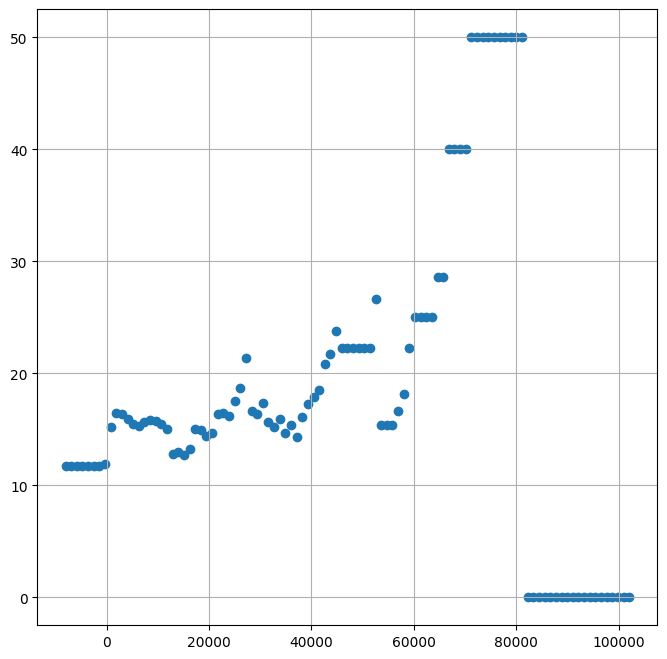

Picking uniformly: 11.698480458295547


In [8]:
t = 360
print(f'Percentage of positive samples for t={t} : {(y[X['balance'] > t]['y'] == 'yes').mean()*100}')

def plot_different_threshold_balance(X, y):
    min_balance, max_balance = X['balance'].min(), X['balance'].max()
    print(min_balance, max_balance)

    xs = []
    ys = []
    for t in range(min_balance, max_balance, (max_balance - min_balance) // 100):
        xs.append(t)
        ys.append((y[X['balance'] > t]['y'] == 'yes').mean()*100)

    plt.figure(figsize=(8,8))
    plt.scatter(xs, ys)
    plt.grid(True)
    plt.show()
plot_different_threshold_balance(X, y)

print(f'Picking uniformly: {(y['y'] == 'yes').mean() * 100}')

In [33]:
idx = np.random.permutation(len(X))
idx1, idx2 = idx[:len(X)//2], idx[len(X)//2:]

X1, X2 = X.iloc[idx1], X.iloc[idx2]
y1, y2 = y.iloc[idx1], y.iloc[idx2]

len(X1), len(X2)

(22605, 22606)

-4057 81204


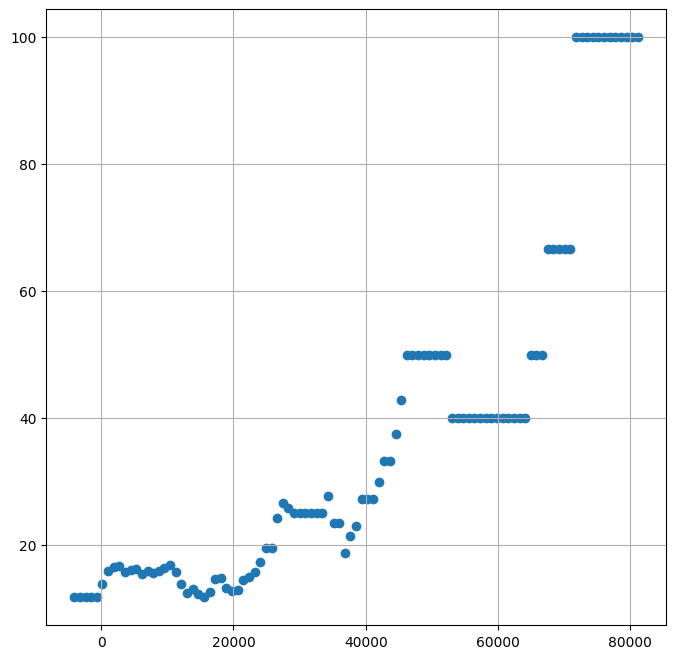

In [34]:
plot_different_threshold_balance(X1, y1)

In [35]:
best_threshold = 70000
print(f'Not interested above threshold: {(y1[X1['balance'] > best_threshold]['y'] == 'no').mean()}')

Not interested above threshold: 0.3333333333333333


In [36]:
print(f'We have not picked {len(y1[X1['balance'] <= best_threshold]['y'] == 'yes')} people that are positive')

We have not picked 22602 people that are positive


In [37]:
len(y1)

22605

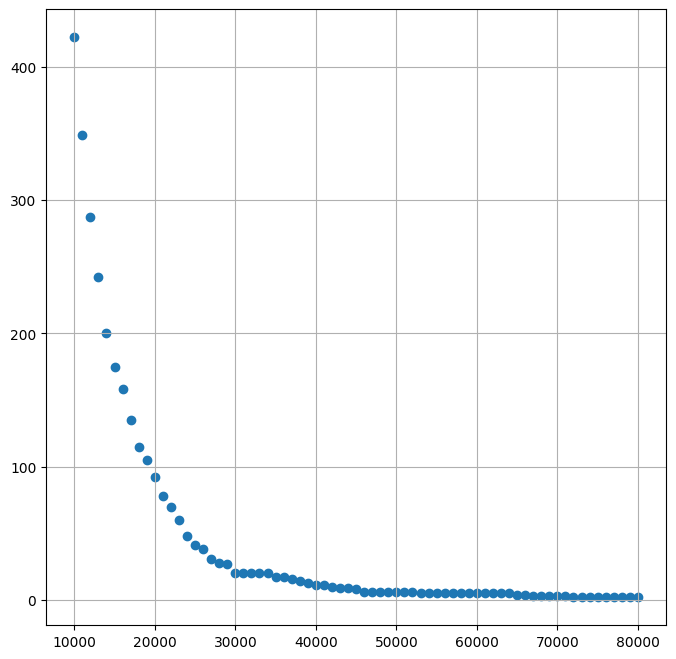

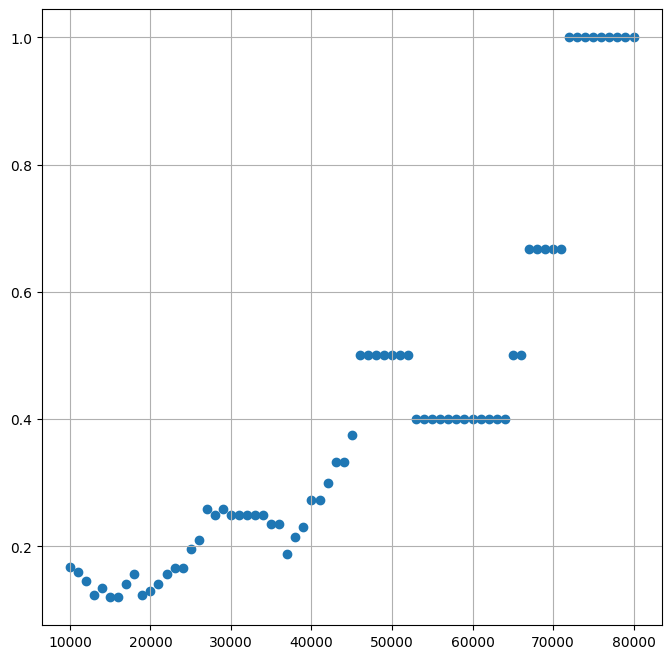

In [48]:
def results_plot():
    xs = []
    ya = []
    yb = []
    for threshold in range(10000, 80000+1, 1000):
        #print(f'Calculating: {threshold}...')
        xs.append(threshold)
        failed_count = len(y1[X1['balance'] > threshold]['y'] == 'yes')
        avg_success = (y1[X1['balance'] > threshold]['y'] == 'yes').mean()
        #print(failed_count, avg_success)
        ya.append(failed_count)
        yb.append(avg_success)
    
    plt.figure(figsize=(8,8))
    plt.scatter(xs, ya)
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,8))
    plt.scatter(xs, yb)
    plt.grid(True)
    plt.show()

results_plot()